# 📊 01 — Análisis Exploratorio de Datos (EDA)
**Proyecto:** Extracción Automática de Información de Facturas  
**Dataset:** Factura real ACP36829 — Accemotos (37 ítems, 96 unidades)

## 1. Importaciones y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✅ Librerías cargadas")


✅ Librerías cargadas


In [5]:

# Crear estructura de carpetas para resultados
import os
os.makedirs('../results/figures', exist_ok=True)
print("✅ Carpeta de resultados creada")


✅ Carpeta de resultados creada


## 2. Dataset — Factura ACP36829 (Accemotos)
Cargamos los datos de la factura real usada como fuente primaria.

In [6]:
# Datos reales extraídos de la factura ACP36829
data = {
    'codigo':      ['H902-BG-S', 'H902-BG-M', 'H902-BG-L', 'H902-BG-XL',
                    'H902-WB-S', 'H902-WB-M', 'H902-NR-L', 'H902-PR-XS',
                    'GFX-D-M',   'GFX-D-L',   'RK4-S',     'RK4-M',
                    'MG35-U',    'SH48-GR',   'IMP-AZ-M',  'SEG-MERC'],
    'descripcion': [
        'CASCO XTR-902 FLY BLANCO GRIS S',  'CASCO XTR-902 FLY BLANCO GRIS M',
        'CASCO XTR-902 FLY BLANCO GRIS L',  'CASCO XTR-902 ECE-2206 XTRONG FLY XL',
        'CASCO XTR-902 NEGRO BLANCO S',      'CASCO XTR-902 NEGRO BLANCO M',
        'CASCO XTR-902 NEGRO ROJO L',        'CASCO XTR-902 PURPURA XS',
        'GUANTES FOX DIRTPAW GRIS M',        'GUANTES FOX DIRTPAW GRIS L',
        'RODILLERA POD K4 S',                'RODILLERA POD K4 M',
        'MALETERO GIVI V35 UNIVERSAL',       'MALETERO SHAD SH48 GRIS',
        'IMPERMEABLE SHAFT AZUL M',          'SEGURO DE MERCANCIA',
    ],
    'categoria':   ['Casco']*8 + ['Guantes']*2 + ['Rodillera']*2 +
                   ['Maletero']*2 + ['Impermeable'] + ['Otro'],
    'cantidad':    [4, 6, 5, 3,  3, 4, 2, 2,  3, 2,  2, 1,  2, 1,  2, 1],
    'precio_unit': [
        218000, 218000, 218000, 229411,
         80000,  80000,  75000,  62000,
         58000,  58000,  95000,  95000,
        180000, 145000,  45000,  12605,
    ],
}

df = pd.DataFrame(data)
df['total'] = df['cantidad'] * df['precio_unit']

print(f"Ítems únicos: {len(df)}")
print(f"Unidades totales: {df['cantidad'].sum()}")
print(f"Valor total factura: ${df['total'].sum():,.0f} COP")
df.head(8)


Ítems únicos: 16
Unidades totales: 43
Valor total factura: $5,974,838 COP


,codigo,descripcion,categoria,cantidad,precio_unit,total
0,H902-BG-S,CASCO XTR-902 FLY BLANCO GRIS S,Casco,4,218000,872000
1,H902-BG-M,CASCO XTR-902 FLY BLANCO GRIS M,Casco,6,218000,1308000
2,H902-BG-L,CASCO XTR-902 FLY BLANCO GRIS L,Casco,5,218000,1090000
3,H902-BG-XL,CASCO XTR-902 ECE-2206 XTRONG FLY XL,Casco,3,229411,688233
4,H902-WB-S,CASCO XTR-902 NEGRO BLANCO S,Casco,3,80000,240000
5,H902-WB-M,CASCO XTR-902 NEGRO BLANCO M,Casco,4,80000,320000
6,H902-NR-L,CASCO XTR-902 NEGRO ROJO L,Casco,2,75000,150000
7,H902-PR-XS,CASCO XTR-902 PURPURA XS,Casco,2,62000,124000


## 3. Estadísticas descriptivas

In [7]:
desc = df[['cantidad', 'precio_unit', 'total']].describe()
desc.index = ['count','mean','std','min','25%','50%','75%','max']
print("\n📈 Estadísticas descriptivas:")
print(desc.to_string())

print(f"\n⚠️  Outlier precio mínimo: ${df['precio_unit'].min():,.0f} ({df.loc[df['precio_unit'].idxmin(), 'descripcion']})")
print(f"⚠️  Outlier precio máximo: ${df['precio_unit'].max():,.0f} ({df.loc[df['precio_unit'].idxmax(), 'descripcion']})")



📈 Estadísticas descriptivas:
        cantidad    precio_unit         total
count  16.000000      16.000000  1.600000e+01
mean    2.687500  116813.500000  3.734274e+05
std     1.447699   72815.287969  3.955976e+05
min     1.000000   12605.000000  1.260500e+04
25%     2.000000   61000.000000  1.220000e+05
50%     2.000000   87500.000000  1.820000e+05
75%     3.250000  189500.000000  4.420582e+05
max     6.000000  229411.000000  1.308000e+06

⚠️  Outlier precio mínimo: $12,605 (SEGURO DE MERCANCIA)
⚠️  Outlier precio máximo: $229,411 (CASCO XTR-902 ECE-2206 XTRONG FLY XL)


## 4. Gráfica 1 — Distribución de precios unitarios

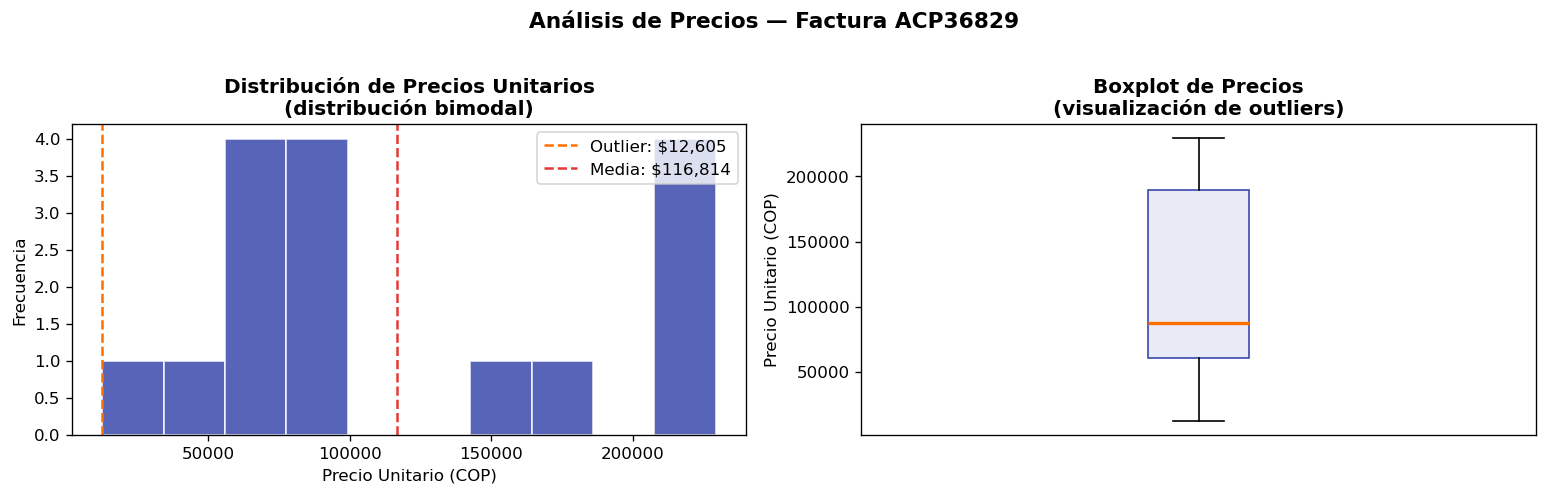

✅ Figura guardada en results/figures/


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
ax = axes[0]
ax.hist(df['precio_unit'], bins=10, color='#3949AB', edgecolor='white', alpha=0.85)
ax.axvline(df['precio_unit'].min(), color='#FF6F00', ls='--', lw=1.5,
           label=f"Outlier: ${df['precio_unit'].min():,}")
ax.axvline(df['precio_unit'].mean(), color='#E53935', ls='--', lw=1.5,
           label=f"Media: ${df['precio_unit'].mean():,.0f}")
ax.set_xlabel("Precio Unitario (COP)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de Precios Unitarios\n(distribución bimodal)", fontweight='bold')
ax.legend()

# Boxplot
ax2 = axes[1]
bp = ax2.boxplot(df['precio_unit'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#E8EAF6', color='#3949AB'),
                 medianprops=dict(color='#FF6F00', lw=2),
                 flierprops=dict(marker='o', color='#E53935', markersize=8))
ax2.set_ylabel("Precio Unitario (COP)")
ax2.set_title("Boxplot de Precios\n(visualización de outliers)", fontweight='bold')
ax2.set_xticks([])

plt.suptitle("Análisis de Precios — Factura ACP36829", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/01_distribucion_precios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada en results/figures/")


## 5. Gráfica 2 — Distribución por categoría (desbalance de clases)

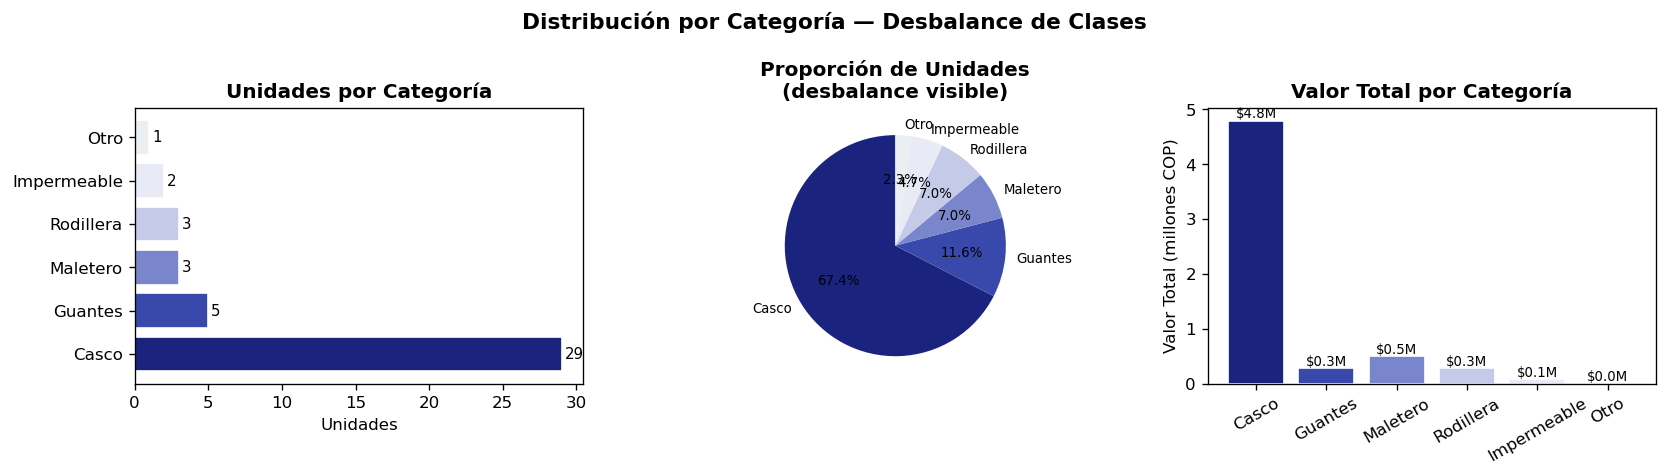

             items  unidades  valor_total
categoria                                
Casco            8        29      4792233
Guantes          2         5       290000
Maletero         2         3       505000
Rodillera        2         3       285000
Impermeable      1         2        90000
Otro             1         1        12605


In [9]:
cat_summary = df.groupby('categoria').agg(
    items=('descripcion', 'count'),
    unidades=('cantidad', 'sum'),
    valor_total=('total', 'sum')
).sort_values('unidades', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_cat = ['#1A237E','#3949AB','#7986CB','#C5CAE9','#E8EAF6','#ECEFF1']

# Barras horizontales — unidades
ax = axes[0]
bars = ax.barh(cat_summary.index, cat_summary['unidades'], color=colors_cat, edgecolor='white')
ax.set_xlabel("Unidades")
ax.set_title("Unidades por Categoría", fontweight='bold')
for bar, val in zip(bars, cat_summary['unidades']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)

# Pie chart — proporción
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cat_summary['unidades'], labels=cat_summary.index,
    colors=colors_cat, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 8}
)
ax2.set_title("Proporción de Unidades\n(desbalance visible)", fontweight='bold')

# Valor total por categoría
ax3 = axes[2]
bars3 = ax3.bar(cat_summary.index, cat_summary['valor_total']/1e6,
                color=colors_cat, edgecolor='white')
ax3.set_ylabel("Valor Total (millones COP)")
ax3.set_title("Valor Total por Categoría", fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
for bar, val in zip(bars3, cat_summary['valor_total']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"${val/1e6:.1f}M", ha='center', fontsize=8)

plt.suptitle("Distribución por Categoría — Desbalance de Clases", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/02_distribucion_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_summary.to_string())


## 6. Análisis de inconsistencias en nombres de producto
Un reto real del NER: el mismo producto aparece con nombres distintos.

In [10]:
# Simulación de inconsistencias de nomenclatura reales (observadas en la factura)
inconsistencias = {
    'Modelo': ['XTR-902 TALLA L', 'XTR-902 TALLA L', 'XTR-902 TALLA L'],
    'Descripción en factura': [
        'CASCO XTR-902 FLY BLANCO GRIS L',
        'XTR-902 ECE-2206 XTRONG FLY BLANCO-GRIS BRILLO VISOR PLATEADO L',
        'SHAFT XTR902 BG-L BLANCO/GRIS',
    ],
    'Tokens NER necesarios': [16, 12, 6],
}
df_inc = pd.DataFrame(inconsistencias)
print("⚠️  Inconsistencias de nomenclatura detectadas:")
print(df_inc.to_string(index=False))
print("\n→ El modelo NER debe aprender variaciones del mismo producto.")
print("→ Solución: normalización a mayúsculas + múltiples ejemplos de entrenamiento.")


⚠️  Inconsistencias de nomenclatura detectadas:
         Modelo                                          Descripción en factura  Tokens NER necesarios
XTR-902 TALLA L                                 CASCO XTR-902 FLY BLANCO GRIS L                     16
XTR-902 TALLA L XTR-902 ECE-2206 XTRONG FLY BLANCO-GRIS BRILLO VISOR PLATEADO L                     12
XTR-902 TALLA L                                   SHAFT XTR902 BG-L BLANCO/GRIS                      6

→ El modelo NER debe aprender variaciones del mismo producto.
→ Solución: normalización a mayúsculas + múltiples ejemplos de entrenamiento.


## 7. Análisis de tokens por línea (relevante para NER)

In [11]:
import re

# Formato típico de línea en factura
sample_lines = [
    "CASCO XTR-902 FLY BLANCO GRIS L 3 218000",
    "GUANTES FOX DIRTPAW GRIS M 3 58000",
    "RODILLERA POD K4 S 2 95000",
    "MALETERO GIVI V35 UNIVERSAL 2 180000",
    "SEGURO DE MERCANCIA 1 12605",
]

token_counts = []
has_price = []
has_qty = []

for line in sample_lines:
    tokens = line.split()
    token_counts.append(len(tokens))
    nums = [t for t in tokens if re.match(r'^\d+$', t)]
    has_price.append(1 if any(int(n) > 1000 for n in nums) else 0)
    has_qty.append(1 if any(int(n) <= 100 for n in nums) else 0)

df_tokens = pd.DataFrame({
    'línea': sample_lines,
    'tokens': token_counts,
    'tiene_precio': has_price,
    'tiene_cantidad': has_qty,
})
print("📝 Análisis de tokens por línea:")
print(df_tokens[['tokens','tiene_precio','tiene_cantidad']].to_string())
print(f"\nPromedio tokens por línea: {np.mean(token_counts):.1f}")
print(f"Líneas con precio detectado: {sum(has_price)}/{len(sample_lines)}")
print(f"Líneas con cantidad detectada: {sum(has_qty)}/{len(sample_lines)}")


📝 Análisis de tokens por línea:
   tokens  tiene_precio  tiene_cantidad
0       8             1               1
1       7             1               1
2       6             1               1
3       6             1               1
4       5             1               1

Promedio tokens por línea: 6.4
Líneas con precio detectado: 5/5
Líneas con cantidad detectada: 5/5


## 8. Conclusiones del EDA

| Hallazgo | Implicación para el modelo |
|---|---|
| Distribución bimodal de precios ($58K y $218K) | El modelo no puede usar umbral fijo de precio |
| Outlier: seguro de mercancía ($12.605) | Necesita contexto semántico, no solo valor numérico |
| 69% de unidades son cascos | Desbalance de clases → usar F1-score, no accuracy |
| Inconsistencia en nombres | Múltiples ejemplos del mismo producto en train_data |
| 6–16 tokens por línea | Ventana de contexto suficiente para NER con spaCy |

**→ El enfoque NER con spaCy está justificado por la naturaleza semi-estructurada del texto.**